In [26]:
import pandas as pd


In [27]:
df = pd.read_excel("ml_dataset.xlsx")

In [28]:
print("Dataset Shape:", df.shape)

Dataset Shape: (437, 5)


In [29]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['road_id', 'hour', 'day', 'delay', 'congestion']


In [30]:
display(df.head(10))

,road_id,hour,day,delay,congestion
0,R1,14,Monday,0.07,FREE
1,R2,14,Monday,-0.65,FREE
2,R3,14,Monday,-0.25,FREE
3,R4,14,Monday,-0.25,FREE
4,R1,16,Monday,-0.23,FREE
5,R2,16,Monday,-0.63,FREE
6,R3,16,Monday,-0.08,FREE
7,R4,16,Monday,-0.42,FREE
8,R1,18,Monday,1.20,LIGHT
9,R2,18,Monday,0.35,FREE


In [31]:
print("DATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

print("\nUNIQUE VALUES")
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())

DATA TYPES
road_id        object
hour            int64
day            object
delay         float64
congestion     object
dtype: object

MISSING VALUES
road_id       0
hour          0
day           0
delay         0
congestion    0
dtype: int64

DUPLICATE ROWS
24

UNIQUE VALUES

road_id:
['R1' 'R2' 'R3' 'R4']

hour:
[14 16 18 22  8 12 15 19 20 21  9 10 11 13 17 23  0]

day:
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']

delay:
[ 0.07 -0.65 -0.25 -0.23 -0.63 -0.08 -0.42  1.2   0.35  1.32  0.45  0.17
 -0.07 -0.32 -0.57 -1.07 -0.87 -1.33 -0.4  -1.3   0.73  0.27  0.02  0.23
  0.48  0.38  0.28  0.22  0.68  2.12  0.57  1.97  1.72 -0.02 -0.13  0.33
 -0.03  0.13 -0.27 -0.72 -1.25 -1.57 -1.   -1.78 -1.37 -1.1   0.1  -0.78
  0.43  0.15  0.05 -0.22  0.37  0.   -0.12  0.65  0.32  0.53  0.3   0.47
  1.85  2.08  1.23  2.22  2.58  1.7   2.4   0.62  2.45  1.88  1.52  2.27
  1.33  0.87  1.02  0.78  3.42  1.18  0.97  0.25  0.03 -1.15 -0.93 -1.48
 -1.13 -1.7  -0.83 -1.53 -0.52 -

In [32]:
print("Number of records in each congestion class:")
print(df["congestion"].value_counts())

Number of records in each congestion class:
congestion
FREE        283
LIGHT        82
MODERATE     53
HEAVY        19
Name: count, dtype: int64


In [33]:
duplicates = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicates))

display(duplicates.sort_values(
    by=["road_id", "hour", "day"]
).head(30))

Total duplicate rows: 41


,road_id,hour,day,delay,congestion
212,R1,19,Friday,3.67,HEAVY
216,R1,19,Friday,3.67,HEAVY
228,R1,19,Friday,4.38,HEAVY
232,R1,19,Friday,4.38,HEAVY
236,R1,19,Friday,4.38,HEAVY
129,R1,19,Thursday,3.70,HEAVY
145,R1,19,Thursday,3.70,HEAVY
78,R2,18,Wednesday,0.22,FREE
82,R2,18,Wednesday,0.22,FREE
225,R2,19,Friday,0.38,FREE


In [34]:
print(df.groupby("congestion")["delay"].agg(
    ["min", "max", "mean", "median"]
))

             min   max      mean  median
congestion                              
FREE       -3.25  0.98 -0.106184   0.080
HEAVY       3.62  5.07  4.148947   4.180
LIGHT       1.00  1.98  1.507805   1.525
MODERATE    2.03  3.48  2.479811   2.350


In [35]:
display(
    df.sort_values("delay")[
        ["road_id", "hour", "day", "delay", "congestion"]
    ].head(30)
)

,road_id,hour,day,delay,congestion
376,R4,0,Tuesday,-3.25,FREE
373,R1,0,Tuesday,-3.07,FREE
308,R4,8,Sunday,-1.93,FREE
48,R4,8,Wednesday,-1.78,FREE
374,R2,0,Tuesday,-1.75,FREE
305,R1,8,Sunday,-1.73,FREE
112,R4,8,Thursday,-1.70,FREE
180,R4,8,Friday,-1.70,FREE
306,R2,8,Sunday,-1.65,FREE
178,R2,8,Friday,-1.58,FREE


In [36]:
display(
    df.sort_values("delay")[
        ["road_id", "hour", "day", "delay", "congestion"]
    ].tail(30)
)

,road_id,hour,day,delay,congestion
425,R1,19,Wednesday,2.80,MODERATE
427,R3,19,Wednesday,2.90,MODERATE
240,R1,19,Friday,2.93,MODERATE
395,R3,20,Tuesday,3.00,MODERATE
423,R3,19,Wednesday,3.00,MODERATE
421,R1,19,Wednesday,3.02,MODERATE
244,R1,20,Friday,3.07,MODERATE
157,R1,19,Thursday,3.37,MODERATE
208,R1,19,Friday,3.38,MODERATE
97,R1,20,Wednesday,3.42,MODERATE


In [37]:
print("Number of records in each congestion class:")
print(df["congestion"].value_counts())

Number of records in each congestion class:
congestion
FREE        283
LIGHT        82
MODERATE     53
HEAVY        19
Name: count, dtype: int64


In [38]:
duplicates = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicates))

display(duplicates.sort_values(
    by=["road_id", "hour", "day"]
).head(30))

Total duplicate rows: 41


,road_id,hour,day,delay,congestion
212,R1,19,Friday,3.67,HEAVY
216,R1,19,Friday,3.67,HEAVY
228,R1,19,Friday,4.38,HEAVY
232,R1,19,Friday,4.38,HEAVY
236,R1,19,Friday,4.38,HEAVY
129,R1,19,Thursday,3.70,HEAVY
145,R1,19,Thursday,3.70,HEAVY
78,R2,18,Wednesday,0.22,FREE
82,R2,18,Wednesday,0.22,FREE
225,R2,19,Friday,0.38,FREE


In [39]:
print(df.groupby("congestion")["delay"].agg(
    ["min", "max", "mean", "median"]
))

             min   max      mean  median
congestion                              
FREE       -3.25  0.98 -0.106184   0.080
HEAVY       3.62  5.07  4.148947   4.180
LIGHT       1.00  1.98  1.507805   1.525
MODERATE    2.03  3.48  2.479811   2.350


In [40]:
display(
    df.sort_values("delay")[
        ["road_id", "hour", "day", "delay", "congestion"]
    ].head(30)
)

display(
    df.sort_values("delay")[
        ["road_id", "hour", "day", "delay", "congestion"]
    ].tail(30)
)

,road_id,hour,day,delay,congestion
376,R4,0,Tuesday,-3.25,FREE
373,R1,0,Tuesday,-3.07,FREE
308,R4,8,Sunday,-1.93,FREE
48,R4,8,Wednesday,-1.78,FREE
374,R2,0,Tuesday,-1.75,FREE
305,R1,8,Sunday,-1.73,FREE
112,R4,8,Thursday,-1.70,FREE
180,R4,8,Friday,-1.70,FREE
306,R2,8,Sunday,-1.65,FREE
178,R2,8,Friday,-1.58,FREE


,road_id,hour,day,delay,congestion
425,R1,19,Wednesday,2.80,MODERATE
427,R3,19,Wednesday,2.90,MODERATE
240,R1,19,Friday,2.93,MODERATE
395,R3,20,Tuesday,3.00,MODERATE
423,R3,19,Wednesday,3.00,MODERATE
421,R1,19,Wednesday,3.02,MODERATE
244,R1,20,Friday,3.07,MODERATE
157,R1,19,Thursday,3.37,MODERATE
208,R1,19,Friday,3.38,MODERATE
97,R1,20,Wednesday,3.42,MODERATE


In [41]:
df_clean = df.drop_duplicates().copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Remaining duplicate rows:", df_clean.duplicated().sum())

Original dataset shape: (437, 5)
Cleaned dataset shape: (413, 5)
Remaining duplicate rows: 0


In [42]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 413 entries, 0 to 436
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   road_id     413 non-null    object 
 1   hour        413 non-null    int64  
 2   day         413 non-null    object 
 3   delay       413 non-null    float64
 4   congestion  413 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 19.4+ KB
None


In [43]:
print(df_clean["congestion"].value_counts())

congestion
FREE        275
LIGHT        76
MODERATE     47
HEAVY        15
Name: count, dtype: int64


In [44]:
X = df_clean[["road_id", "hour", "day"]]

y = df_clean["congestion"]

print("Input features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Input features (X):
  road_id  hour     day
0      R1    14  Monday
1      R2    14  Monday
2      R3    14  Monday
3      R4    14  Monday
4      R1    16  Monday

Target (y):
0    FREE
1    FREE
2    FREE
3    FREE
4    FREE
Name: congestion, dtype: object


In [45]:
X_encoded = pd.get_dummies(X, columns=["road_id", "day"])

print("Encoded X:")
display(X_encoded.head())

print("\nShape of encoded X:", X_encoded.shape)


Encoded X:


,hour,road_id_R1,road_id_R2,road_id_R3,road_id_R4,day_Friday,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,14,True,False,False,False,False,True,False,False,False,False,False
1,14,False,True,False,False,False,True,False,False,False,False,False
2,14,False,False,True,False,False,True,False,False,False,False,False
3,14,False,False,False,True,False,True,False,False,False,False,False
4,16,True,False,False,False,False,True,False,False,False,False,False



Shape of encoded X: (413, 12)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (330, 12)
Testing data: (83, 12)


In [47]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [48]:
y_pred = model.predict(X_test)

print("Predictions completed successfully!")
print("\nFirst 10 Predictions:")
print(y_pred[:10])

Predictions completed successfully!

First 10 Predictions:
['FREE' 'FREE' 'LIGHT' 'FREE' 'MODERATE' 'FREE' 'FREE' 'MODERATE' 'LIGHT'
 'FREE']


In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", round(accuracy * 100, 2), "%")

Model Accuracy: 0.8072289156626506
Model Accuracy (%): 80.72 %


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        FREE       0.96      0.93      0.94        55
       HEAVY       0.75      1.00      0.86         3
       LIGHT       0.56      0.67      0.61        15
    MODERATE       0.38      0.30      0.33        10

    accuracy                           0.81        83
   macro avg       0.66      0.72      0.69        83
weighted avg       0.81      0.81      0.81        83



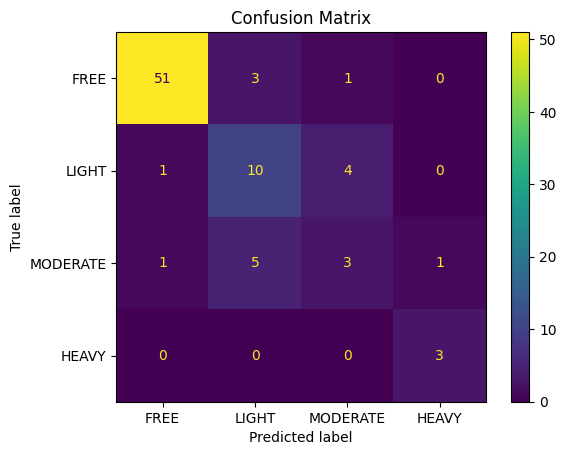

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["FREE", "LIGHT", "MODERATE", "HEAVY"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FREE", "LIGHT", "MODERATE", "HEAVY"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [52]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

Feature Importance:
hour             0.478015
road_id_R1       0.122107
road_id_R2       0.061748
day_Wednesday    0.055247
road_id_R3       0.052582
day_Saturday     0.041151
day_Thursday     0.038990
road_id_R4       0.038917
day_Friday       0.035721
day_Tuesday      0.030684
day_Monday       0.025677
day_Sunday       0.019162
dtype: float64


In [53]:
import joblib

joblib.dump(model, "traffic_congestion_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [54]:
loaded_model = joblib.load("traffic_congestion_model.pkl")

test_prediction = loaded_model.predict(X_test)

print("Saved model loaded successfully!")
print("First 10 predictions:")
print(test_prediction[:10])

Saved model loaded successfully!
First 10 predictions:
['FREE' 'FREE' 'LIGHT' 'FREE' 'MODERATE' 'FREE' 'FREE' 'MODERATE' 'LIGHT'
 'FREE']


In [55]:
df_clean.to_csv("ml_dataset_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [56]:
import os

print("Files created in Colab:")
print(os.listdir())

Files created in Colab:
['.config', 'ml_dataset.xlsx', 'traffic_congestion_model.pkl', 'ml_dataset_cleaned.csv', 'sample_data']


In [57]:
def predict_congestion(road_id, hour, day):

    new_data = pd.DataFrame({
        "road_id": [road_id],
        "hour": [hour],
        "day": [day]
    })

    new_data_encoded = pd.get_dummies(
        new_data,
        columns=["road_id", "day"]
    )

    new_data_encoded = new_data_encoded.reindex(
        columns=X_encoded.columns,
        fill_value=False
    )

    prediction = loaded_model.predict(new_data_encoded)

    return prediction[0]


print("Prediction function created successfully!")

Prediction function created successfully!


In [58]:
result = predict_congestion("R1", 18, "Monday")

print("Predicted Congestion:", result)

Predicted Congestion: LIGHT


In [59]:
test_cases = [
    ("R1", 8, "Monday"),
    ("R2", 18, "Monday"),
    ("R3", 14, "Wednesday"),
    ("R4", 20, "Friday")
]

for road, hour, day in test_cases:
    prediction = predict_congestion(road, hour, day)
    print(f"{road} | {hour}:00 | {day} → {prediction}")

R1 | 8:00 | Monday → FREE
R2 | 18:00 | Monday → FREE
R3 | 14:00 | Wednesday → FREE
R4 | 20:00 | Friday → LIGHT


In [60]:
joblib.dump(X_encoded.columns.tolist(), "traffic_model_features.pkl")

print("Feature information saved successfully!")

Feature information saved successfully!


In [61]:
import os

files = [
    "ml_dataset_cleaned.csv",
    "traffic_congestion_model.pkl",
    "traffic_model_features.pkl"
]

for file in files:
    if os.path.exists(file):
        print(file, "exists")
    else:
        print(file, "not found")

ml_dataset_cleaned.csv exists
traffic_congestion_model.pkl exists
traffic_model_features.pkl exists


In [62]:
hour_congestion = pd.crosstab(
    df_clean["hour"],
    df_clean["congestion"]
)

display(hour_congestion)

congestion,FREE,HEAVY,LIGHT,MODERATE
hour,,,,
0,4,0,0,0
8,37,0,0,0
9,16,0,0,0
10,20,0,0,0
11,28,0,0,0
12,7,0,1,0
13,12,0,0,0
14,11,0,2,0
15,10,0,2,0


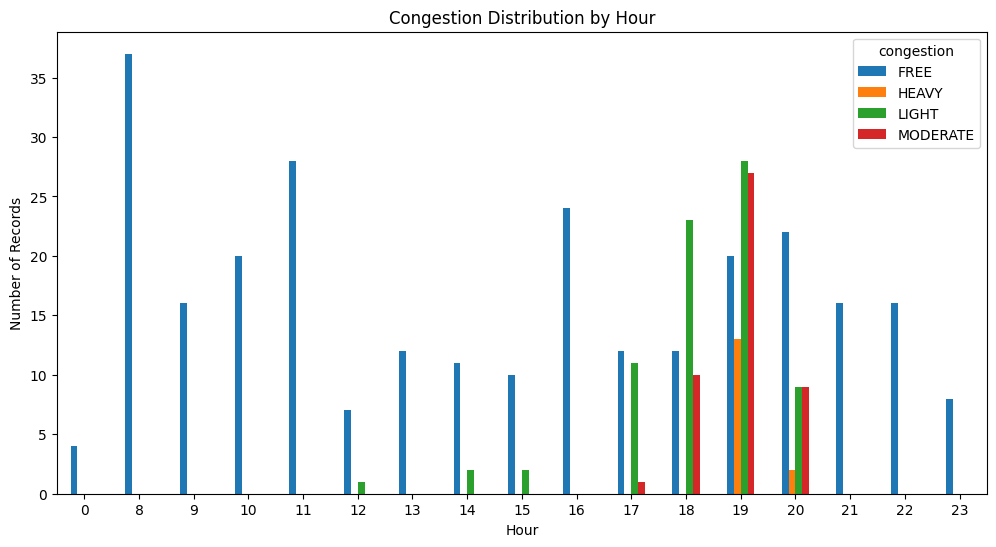

In [63]:
hour_congestion.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Congestion Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [64]:
road_congestion = pd.crosstab(
    df_clean["road_id"],
    df_clean["congestion"]
)

display(road_congestion)

congestion,FREE,HEAVY,LIGHT,MODERATE
road_id,,,,
R1,57,15,19,16
R2,96,0,4,0
R3,58,0,25,21
R4,64,0,28,10


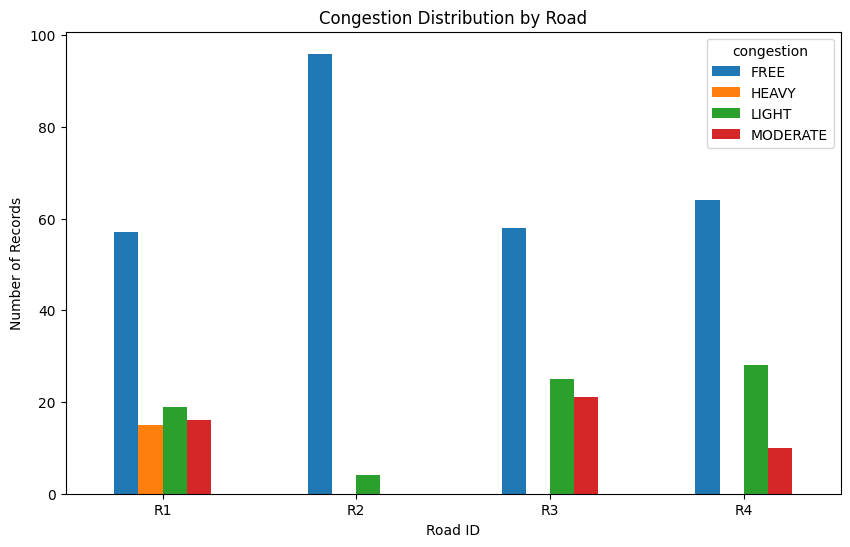

In [65]:
road_congestion.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Congestion Distribution by Road")
plt.xlabel("Road ID")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [66]:
day_congestion = pd.crosstab(
    df_clean["day"],
    df_clean["congestion"]
)

display(day_congestion)

congestion,FREE,HEAVY,LIGHT,MODERATE
day,,,,
Friday,35,4,13,16
Monday,45,3,10,2
Saturday,29,0,16,4
Sunday,22,0,6,0
Thursday,33,6,13,6
Tuesday,43,2,8,6
Wednesday,68,0,10,13


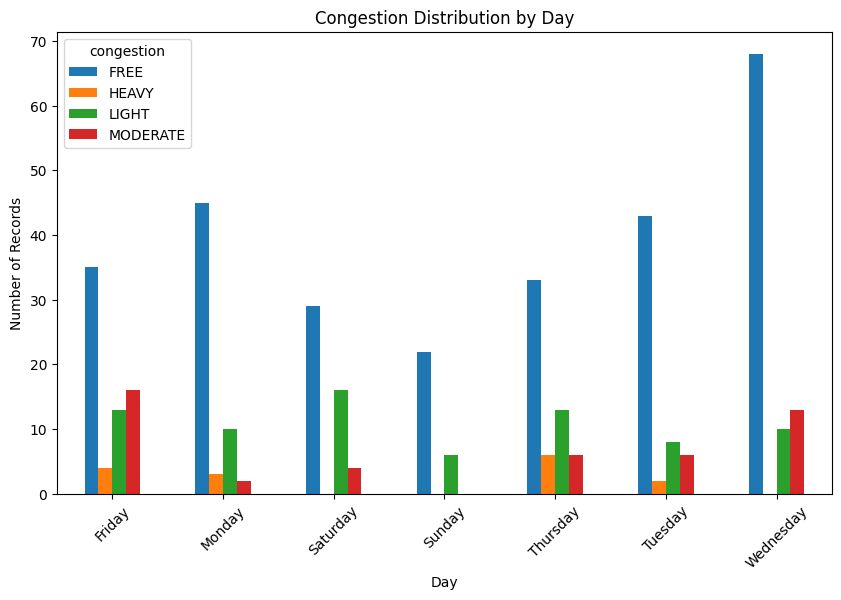

In [67]:
day_congestion.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Congestion Distribution by Day")
plt.xlabel("Day")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [68]:
day_congestion.to_csv("congestion_by_day.csv")

print("Day-wise congestion analysis saved successfully!")

Day-wise congestion analysis saved successfully!


In [69]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(results.head(20))

,Actual,Predicted
0,FREE,FREE
1,FREE,FREE
2,LIGHT,LIGHT
3,FREE,FREE
4,MODERATE,MODERATE
5,FREE,FREE
6,FREE,FREE
7,LIGHT,MODERATE
8,MODERATE,LIGHT
9,FREE,FREE


In [70]:
correct = (results["Actual"] == results["Predicted"]).sum()
incorrect = (results["Actual"] != results["Predicted"]).sum()

print("Correct Predictions:", correct)
print("Incorrect Predictions:", incorrect)
print("Total Predictions:", len(results))

Correct Predictions: 67
Incorrect Predictions: 16
Total Predictions: 83


In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("MODEL PERFORMANCE")
print("-----------------")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1-Score :", round(f1 * 100, 2), "%")

MODEL PERFORMANCE
-----------------
Accuracy : 80.72 %
Precision: 81.03 %
Recall   : 80.72 %
F1-Score : 80.65 %


In [72]:
import os

print("Important project files:")

for file in [
    "traffic_congestion_model.pkl",
    "traffic_model_features.pkl",
    "ml_dataset_cleaned.csv",
    "congestion_by_day.csv"
]:
    print(file, "→", "Available" if os.path.exists(file) else "Missing")

Important project files:
traffic_congestion_model.pkl → Available
traffic_model_features.pkl → Available
ml_dataset_cleaned.csv → Available
congestion_by_day.csv → Available


In [73]:
import os

os.makedirs("models", exist_ok=True)

print("Models folder created successfully!")

Models folder created successfully!


In [74]:
import shutil

shutil.copy(
    "traffic_congestion_model.pkl",
    "models/traffic_congestion_model.pkl"
)

shutil.copy(
    "traffic_model_features.pkl",
    "models/traffic_model_features.pkl"
)

print("Model files copied successfully!")

Model files copied successfully!


In [75]:
import os

print("Files inside models folder:")

for file in os.listdir("models"):
    print(file)


Files inside models folder:
traffic_congestion_model.pkl
traffic_model_features.pkl


In [76]:
import os

os.makedirs("data/processed", exist_ok=True)

print("Processed data folder created successfully!")

Processed data folder created successfully!


In [77]:
import shutil

shutil.copy(
    "ml_dataset_cleaned.csv",
    "data/processed/ml_dataset_cleaned.csv"
)

print("Cleaned dataset copied successfully!")

Cleaned dataset copied successfully!


In [78]:
import os

print("DATA SCIENCE PROJECT STRUCTURE")
print("--------------------------------")

for root, dirs, files in os.walk("."):
    # Skip unnecessary Colab/system folders
    if root.startswith("./.config") or root.startswith("./sample_data"):
        continue

    level = root.count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

DATA SCIENCE PROJECT STRUCTURE
--------------------------------
./
    ml_dataset.xlsx
    traffic_congestion_model.pkl
    traffic_model_features.pkl
    ml_dataset_cleaned.csv
    congestion_by_day.csv
    models/
        traffic_congestion_model.pkl
        traffic_model_features.pkl
    data/
        processed/
            ml_dataset_cleaned.csv


In [79]:
import joblib

model_path = "models/traffic_congestion_model.pkl"
features_path = "models/traffic_model_features.pkl"

loaded_model = joblib.load(model_path)
model_features = joblib.load(features_path)

print("✅ Model loaded successfully!")
print("✅ Feature information loaded successfully!")

print("\nNumber of model features:", len(model_features))
print("Model features:")
print(model_features)

✅ Model loaded successfully!
✅ Feature information loaded successfully!

Number of model features: 12
Model features:
['hour', 'road_id_R1', 'road_id_R2', 'road_id_R3', 'road_id_R4', 'day_Friday', 'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']


In [80]:
import pandas as pd

def predict_congestion_final(road_id, hour, day):

    new_data = pd.DataFrame({
        "road_id": [road_id],
        "hour": [hour],
        "day": [day]
    })

    # Convert categorical values into the same format used during training
    new_data_encoded = pd.get_dummies(
        new_data,
        columns=["road_id", "day"]
    )

    # Make sure all 12 model features are present
    new_data_encoded = new_data_encoded.reindex(
        columns=model_features,
        fill_value=False
    )

    prediction = loaded_model.predict(new_data_encoded)

    return prediction[0]


result = predict_congestion_final("R1", 18, "Monday")

print("Road ID:", "R1")
print("Hour:", "18:00")
print("Day:", "Monday")
print("Predicted Congestion:", result)

Road ID: R1
Hour: 18:00
Day: Monday
Predicted Congestion: LIGHT


In [81]:
prediction_code = '''
import pandas as pd
import joblib

# Load trained model and feature information
model = joblib.load("models/traffic_congestion_model.pkl")
model_features = joblib.load("models/traffic_model_features.pkl")


def predict_congestion(road_id, hour, day):

    new_data = pd.DataFrame({
        "road_id": [road_id],
        "hour": [hour],
        "day": [day]
    })

    # Apply the same encoding used during training
    new_data_encoded = pd.get_dummies(
        new_data,
        columns=["road_id", "day"]
    )

    # Match the exact features used by the model
    new_data_encoded = new_data_encoded.reindex(
        columns=model_features,
        fill_value=False
    )

    prediction = model.predict(new_data_encoded)

    return prediction[0]


if __name__ == "__main__":

    result = predict_congestion("R1", 18, "Monday")

    print("Predicted Congestion:", result)
'''

with open("predict.py", "w") as file:
    file.write(prediction_code)

print("✅ predict.py created successfully!")

✅ predict.py created successfully!


In [82]:
!python predict.py

Predicted Congestion: LIGHT


In [83]:
from predict import predict_congestion

test_cases = [
    ("R1", 8, "Monday"),
    ("R1", 19, "Friday"),
    ("R3", 18, "Wednesday"),
    ("R4", 20, "Friday")
]

print("TRAFFIC CONGESTION PREDICTIONS")
print("--------------------------------")

for road, hour, day in test_cases:
    prediction = predict_congestion(road, hour, day)
    print(f"{road} | {hour}:00 | {day} → {prediction}")

TRAFFIC CONGESTION PREDICTIONS
--------------------------------
R1 | 8:00 | Monday → FREE
R1 | 19:00 | Friday → HEAVY
R3 | 18:00 | Wednesday → MODERATE
R4 | 20:00 | Friday → LIGHT


In [84]:
import os

os.makedirs("src", exist_ok=True)

print("✅ src folder created successfully!")

✅ src folder created successfully!


In [85]:
import shutil
import os

shutil.move(
    "predict.py",
    "src/predict.py"
)

print("✅ predict.py moved to src folder successfully!")
print("File exists:", os.path.exists("src/predict.py"))

✅ predict.py moved to src folder successfully!
File exists: True


In [86]:
!python src/predict.py

Predicted Congestion: LIGHT


In [87]:
with open("src/__init__.py", "w") as file:
    file.write("")

print("✅ __init__.py created successfully!")

✅ __init__.py created successfully!


In [88]:
api_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
from predict import predict_congestion

app = FastAPI(
    title="Smart Traffic Prediction API",
    description="ML API for traffic congestion prediction",
    version="1.0"
)


class TrafficInput(BaseModel):
    road_id: str
    hour: int
    day: str


@app.get("/")
def home():
    return {
        "message": "Smart Traffic Prediction API is running"
    }


@app.post("/predict")
def predict(data: TrafficInput):

    result = predict_congestion(
        data.road_id,
        data.hour,
        data.day
    )

    return {
        "road_id": data.road_id,
        "hour": data.hour,
        "day": data.day,
        "predicted_congestion": result
    }
'''

with open("src/api.py", "w") as file:
    file.write(api_code)

print("✅ api.py created successfully!")

✅ api.py created successfully!


In [89]:
!pip install fastapi uvicorn

In [90]:
import sys

sys.path.append("src")

try:
    import api
    print("✅ api.py loaded successfully!")
    print("✅ No import errors found!")
except Exception as e:
    print("❌ Error:", e)

✅ api.py loaded successfully!
✅ No import errors found!


In [91]:
api_path = "src/api.py"

with open(api_path, "r") as file:
    api_code = file.read()

api_code = api_code.replace(
    "from predict import predict_congestion",
    "from .predict import predict_congestion"
)

with open(api_path, "w") as file:
    file.write(api_code)

print("✅ api.py import fixed successfully!")

✅ api.py import fixed successfully!


In [92]:
!python -c "import sys; sys.path.insert(0, '.'); import src.api; print('✅ API imported successfully!')"

✅ API imported successfully!


In [93]:
!uvicorn src.api:app --host 0.0.0.0 --port 8000

INFO:     Started server process [3895]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Finished server process [3895]
ERROR:    Traceback (most recent call last):
  File "/usr/lib/python3.13/asyncio/runners.py", line 196, in run
    return runner.run(main)
           ~~~~~~~~~~^^^^^^
  File "/usr/lib/python3.13/asyncio/runners.py", line 119, in run
    return self._loop.run_until_complete(task)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "uvloop/loop.pyx", line 1512, in uvloop.loop.Loop.run_until_complete
  File "uvloop/loop.pyx", line 1505, in uvloop.loop.Loop.run_until_complete
    self.run_forever()
  File "uvloop/loop.pyx", line 1379, in uvloop.loop.Loop.run_forever
    self._run(mode)
  File "uvloop/loop.pyx", line 557, in uvloop.loop.Loop._run
    raise self._last_error
  File "uvloop/loop.pyx", line 476, in uvloop.loop.Loop._on_i

In [94]:
import subprocess
import time

server = subprocess.Popen(
    ["uvicorn", "src.api:app", "--host", "0.0.0.0", "--port", "8000"]
)

time.sleep(3)

print("✅ FastAPI server started in the background!")
print("PID:", server.pid)

✅ FastAPI server started in the background!
PID: 4224


In [95]:
import requests

response = requests.get("http://127.0.0.1:8000/")

print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 200
Response: {'message': 'Smart Traffic Prediction API is running'}


In [96]:
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "road_id": "R1",
    "hour": 18,
    "day": "Monday"
}

response = requests.post(url, json=data)

print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 200
Response: {'road_id': 'R1', 'hour': 18, 'day': 'Monday', 'predicted_congestion': 'LIGHT'}


In [97]:
import requests

url = "http://127.0.0.1:8000/predict"

test_cases = [
    {
        "road_id": "R1",
        "hour": 8,
        "day": "Monday"
    },
    {
        "road_id": "R1",
        "hour": 19,
        "day": "Friday"
    },
    {
        "road_id": "R3",
        "hour": 18,
        "day": "Wednesday"
    },
    {
        "road_id": "R4",
        "hour": 20,
        "day": "Friday"
    }
]

print("API PREDICTION TEST")
print("-------------------")

for data in test_cases:

    response = requests.post(url, json=data)

    result = response.json()

    print(
        f"{data['road_id']} | "
        f"{data['hour']}:00 | "
        f"{data['day']} → "
        f"{result['predicted_congestion']}"
    )

API PREDICTION TEST
-------------------
R1 | 8:00 | Monday → FREE
R1 | 19:00 | Friday → HEAVY
R3 | 18:00 | Wednesday → MODERATE
R4 | 20:00 | Friday → LIGHT


In [98]:
requirements = """pandas
numpy
openpyxl
scikit-learn
matplotlib
seaborn
joblib
fastapi
uvicorn
pydantic
requests
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("✅ requirements.txt created successfully!")

✅ requirements.txt created successfully!


In [99]:
with open("requirements.txt", "r") as file:
    print(file.read())

pandas
numpy
openpyxl
scikit-learn
matplotlib
seaborn
joblib
fastapi
uvicorn
pydantic
requests



In [100]:
import os

folders = [
    "data/raw",
    "data/processed",
    "models",
    "notebooks",
    "src"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ All project folders are ready!")

for folder in folders:
    print("📁", folder)

✅ All project folders are ready!
📁 data/raw
📁 data/processed
📁 models
📁 notebooks
📁 src


In [101]:
import os

important_files = [
    "models/traffic_congestion_model.pkl",
    "models/traffic_model_features.pkl",
    "data/processed/ml_dataset_cleaned.csv",
    "src/predict.py",
    "src/api.py",
    "src/__init__.py",
    "requirements.txt"
]

print("IMPORTANT PROJECT FILES")
print("-----------------------")

for file in important_files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

IMPORTANT PROJECT FILES
-----------------------
✅ models/traffic_congestion_model.pkl
✅ models/traffic_model_features.pkl
✅ data/processed/ml_dataset_cleaned.csv
✅ src/predict.py
✅ src/api.py
✅ src/__init__.py
✅ requirements.txt


In [102]:
import shutil
import os

shutil.copy(
    "ml_dataset.xlsx",
    "data/raw/ml_dataset.xlsx"
)

print("✅ Original dataset copied to data/raw successfully!")
print(
    "File exists:",
    os.path.exists("data/raw/ml_dataset.xlsx")
)

✅ Original dataset copied to data/raw successfully!
File exists: True


In [103]:
gitignore_content = """# Datasets
data/raw/
data/processed/

# Trained ML models
models/*.pkl
models/*.joblib

# Python
__pycache__/
*.py[cod]
.venv/
venv/

# Jupyter
.ipynb_checkpoints/

# VS Code
.vscode/

# Colab
sample_data/
"""

with open(".gitignore", "w") as file:
    file.write(gitignore_content)

print("✅ .gitignore created successfully!")

✅ .gitignore created successfully!


In [104]:
with open(".gitignore", "r") as file:
    print(file.read())

# Datasets
data/raw/
data/processed/

# Trained ML models
models/*.pkl
models/*.joblib

# Python
__pycache__/
*.py[cod]
.venv/
venv/

# Jupyter
.ipynb_checkpoints/

# VS Code
.vscode/

# Colab
sample_data/



In [105]:
import os

print("FINAL DATA SCIENCE PROJECT STRUCTURE")
print("------------------------------------")

for root, dirs, files in os.walk("."):
    # Ignore Colab system folders
    dirs[:] = [
        d for d in dirs
        if d not in [".config", "sample_data", "__pycache__"]
    ]

    level = root.count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        if file != ".ipynb_checkpoints":
            print(f"{indent}    {file}")

FINAL DATA SCIENCE PROJECT STRUCTURE
------------------------------------
./
    .gitignore
    requirements.txt
    ml_dataset.xlsx
    traffic_congestion_model.pkl
    traffic_model_features.pkl
    ml_dataset_cleaned.csv
    congestion_by_day.csv
    src/
        api.py
        __init__.py
        predict.py
    models/
        traffic_congestion_model.pkl
        traffic_model_features.pkl
    notebooks/
    data/
        raw/
            ml_dataset.xlsx
        processed/
            ml_dataset_cleaned.csv


In [106]:
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "road_id": "R1",
    "hour": 19,
    "day": "Friday"
}

response = requests.post(url, json=data)

print("Status Code:", response.status_code)
print("API Response:", response.json())

Status Code: 200
API Response: {'road_id': 'R1', 'hour': 19, 'day': 'Friday', 'predicted_congestion': 'HEAVY'}


In [107]:
api_path = "src/api.py"

with open(api_path, "r") as file:
    api_code = file.read()

api_code = api_code.replace(
    "from pydantic import BaseModel",
    "from pydantic import BaseModel, Field"
)

api_code = api_code.replace(
    '''class TrafficInput(BaseModel):
    road_id: str
    hour: int
    day: str''',
    '''class TrafficInput(BaseModel):
    road_id: str
    hour: int = Field(..., ge=0, le=23)
    day: str'''
)

with open(api_path, "w") as file:
    file.write(api_code)

print("✅ API input validation added successfully!")

✅ API input validation added successfully!


In [108]:
import sys
import importlib

try:
    sys.path.insert(0, ".")
    import src.api
    importlib.reload(src.api)

    print("✅ Updated API loaded successfully!")
    print("✅ Input validation is working in the API code!")

except Exception as e:
    print("❌ Error:", e)

✅ Updated API loaded successfully!
✅ Input validation is working in the API code!


In [109]:
server.terminate()
server.wait()

print("✅ Old API server stopped successfully!")

server = subprocess.Popen(
    ["uvicorn", "src.api:app", "--host", "0.0.0.0", "--port", "8000"]
)

import time
time.sleep(3)

print("✅ Updated FastAPI server started successfully!")
print("PID:", server.pid)

✅ Old API server stopped successfully!
✅ Updated FastAPI server started successfully!
PID: 4252


In [110]:
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "road_id": "R1",
    "hour": 19,
    "day": "Friday"
}

response = requests.post(url, json=data)

print("Status Code:", response.status_code)
print("API Response:", response.json())

Status Code: 200
API Response: {'road_id': 'R1', 'hour': 19, 'day': 'Friday', 'predicted_congestion': 'HEAVY'}


In [111]:
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "road_id": "R1",
    "hour": 25,
    "day": "Friday"
}

response = requests.post(url, json=data)

print("Status Code:", response.status_code)
print("API Response:", response.json())

Status Code: 422
API Response: {'detail': [{'type': 'less_than_equal', 'loc': ['body', 'hour'], 'msg': 'Input should be less than or equal to 23', 'input': 25, 'ctx': {'le': 23}}]}


In [112]:
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "road_id": "R3",
    "hour": 18,
    "day": "Wednesday"
}

response = requests.post(url, json=data)

print("Status Code:", response.status_code)
print("API Response:", response.json())

Status Code: 200
API Response: {'road_id': 'R3', 'hour': 18, 'day': 'Wednesday', 'predicted_congestion': 'MODERATE'}


In [113]:
api_code = '''
from fastapi import FastAPI
from pydantic import BaseModel, Field
from .predict import predict_congestion

app = FastAPI(
    title="Smart Traffic Prediction API",
    description="ML API for traffic congestion prediction",
    version="1.0"
)

class TrafficInput(BaseModel):
    road_id: str
    hour: int = Field(..., ge=0, le=23)
    day: str = Field(
        ...,
        pattern="^(Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)$"
    )

@app.get("/")
def home():
    return {"message": "Smart Traffic Prediction API is running"}

@app.post("/predict")
def predict(data: TrafficInput):
    result = predict_congestion(
        data.road_id,
        data.hour,
        data.day
    )

    return {
        "road_id": data.road_id,
        "hour": data.hour,
        "day": data.day,
        "predicted_congestion": result
    }
'''

with open("src/api.py", "w") as f:
    f.write(api_code)

print("src/api.py updated successfully!")

src/api.py updated successfully!


In [114]:
server.terminate()
server.wait()

import subprocess
import time

server = subprocess.Popen(
    ["uvicorn", "src.api:app", "--host", "0.0.0.0", "--port", "8000"]
)

time.sleep(3)

print("FastAPI server restarted successfully!")

FastAPI server restarted successfully!


In [115]:
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "road_id": "R1",
    "hour": 18,
    "day": "Funday"
}

response = requests.post(url, json=data)

print("Status Code:", response.status_code)
print("API Response:", response.json())

Status Code: 422
API Response: {'detail': [{'type': 'string_pattern_mismatch', 'loc': ['body', 'day'], 'msg': "String should match pattern '^(Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)$'", 'input': 'Funday', 'ctx': {'pattern': '^(Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)$'}}]}


In [116]:
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "road_id": "R1",
    "hour": 19,
    "day": "Friday"
}

response = requests.post(url, json=data)

print("Status Code:", response.status_code)
print("API Response:", response.json())

Status Code: 200
API Response: {'road_id': 'R1', 'hour': 19, 'day': 'Friday', 'predicted_congestion': 'HEAVY'}


In [117]:
import requests

response = requests.get("http://127.0.0.1:8000/docs")

print("Status Code:", response.status_code)
print("FastAPI Documentation is available at:")
print("http://127.0.0.1:8000/docs")


Status Code: 200
FastAPI Documentation is available at:
http://127.0.0.1:8000/docs


In [118]:
from google.colab import output

url = output.eval_js("google.colab.kernel.proxyPort(8000)")

print("Open this URL in your browser:")
print(url)

Open this URL in your browser:
https://8000-m-s-kkb-use4c2-1wj3w47sykbbd-c.us-east4-2.prod.colab.dev


In [119]:
import requests

response = requests.get("http://127.0.0.1:8000/")

print(response.status_code)
print(response.json())

200
{'message': 'Smart Traffic Prediction API is running'}


In [120]:
from google.colab import output

url = output.eval_js("google.colab.kernel.proxyPort(8000)")
print(url + "/docs")

https://8000-m-s-kkb-use4c2-1wj3w47sykbbd-c.us-east4-2.prod.colab.dev/docs


In [121]:
test_code = '''
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "road_id": "R1",
    "hour": 19,
    "day": "Friday"
}

response = requests.post(url, json=data)

print("Status Code:", response.status_code)
print("Prediction:", response.json()["predicted_congestion"])
'''

with open("test_api.py", "w") as f:
    f.write(test_code)

print("test_api.py created successfully!")

test_api.py created successfully!


In [122]:
!python test_api.py

Status Code: 200
Prediction: HEAVY


In [123]:
import os

files_to_check = [
    "requirements.txt",
    ".gitignore",
    "src/api.py",
    "src/predict.py",
    "src/__init__.py",
    "models/traffic_congestion_model.pkl",
    "models/traffic_model_features.pkl",
    "data/processed/ml_dataset_cleaned.csv"
]

for file in files_to_check:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌ MISSING:", file)

✅ requirements.txt
✅ .gitignore
✅ src/api.py
✅ src/predict.py
✅ src/__init__.py
✅ models/traffic_congestion_model.pkl
✅ models/traffic_model_features.pkl
✅ data/processed/ml_dataset_cleaned.csv


In [124]:
!git status --short

fatal: not a git repository (or any of the parent directories): .git


In [125]:
import shutil

shutil.make_archive("src_files", "zip", "src")

print("src_files.zip created successfully!")

src_files.zip created successfully!


In [126]:
import os

print("Models folder exists:", os.path.exists("models"))

if os.path.exists("models"):
    print("Files inside models:")
    print(os.listdir("models"))

Models folder exists: True
Files inside models:
['traffic_congestion_model.pkl', 'traffic_model_features.pkl']


In [127]:
import os

matches = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file in [
            "traffic_congestion_model.pkl",
            "traffic_model_features.pkl"
        ]:
            matches.append(os.path.join(root, file))

print("Found model files:")
for file in matches:
    print("✅", file)

if not matches:
    print("❌ Model files are not available in this Colab session.")

Found model files:
✅ /content/traffic_congestion_model.pkl
✅ /content/traffic_model_features.pkl
✅ /content/models/traffic_congestion_model.pkl
✅ /content/models/traffic_model_features.pkl


In [128]:
from google.colab import files

files.download("models/traffic_congestion_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [129]:
from google.colab import files

files.download("models/traffic_model_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [135]:
from google.colab import files

files.download("data/processed/ml_dataset_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [134]:
import os

print(os.listdir("data/processed"))

['ml_dataset_cleaned.csv']
